# Practice Notebook: Regression & Classification Analysis with Python

## A Story of Predictive Modeling for Social Impact

**Meet Amani**, a data scientist at **Resilient Futures**, an NGO focused on building sustainable solutions for communities facing climate change and food insecurity across Africa. Her director has given her two critical assignments:

1.  **Predicting Climate Resilience**: Build a model that predicts a community's resilience score based on environmental and socio-economic factors, so the NGO can identify vulnerable communities before a crisis hits.
2.  **Classifying Climate Risk**: Develop a model that classifies a community's climate risk level (Low, Medium, or High), enabling the NGO to prioritize its limited resources effectively.

Amani will work through multiple machine learning techniques for each task, comparing their strengths and weaknesses. For each technique, she follows a consistent 6-step workflow: **Loading, Exploring, Cleaning, Preparing, Modeling, and Evaluating**. After each example, you will face a challenge to apply the same technique to an agrifood dataset.

This notebook covers:

| Part | Goal | Techniques |
|:---|:---|:---|
| **Part 1: Regression** | Predict `resilience_score` (continuous) | Multiple Linear Regression, Polynomial Regression, Decision Tree, KNN, SVR |
| **Part 2: Classification** | Predict `climate_risk_level` (categorical) | Logistic Regression, Decision Tree, Naive Bayes, KNN, SVM |

You can download the [datasets here](https://drive.google.com/drive/folders/1aR2p_YKvIDp61mAg3dIsCqVoGAFvc2XR?usp=sharing).


---
# Part 2: Classification Analysis

Having completed her regression analysis, Amani now turns to her second assignment: predicting a community's **`climate_risk_level`** (Low, Medium, or High). This is a **classification** problem because the target variable is categorical, not continuous. She will use the `climate_risk_classification.csv` dataset for examples. For the challenges, you will predict **`food_security_status`** (Insecure, Moderate, Secure) using the `agrifood_food_security.csv` dataset.

**Key Difference from Regression**: In regression, we predict a number. In classification, we predict a category. This means the evaluation metrics are completely different. Instead of MAE and R2, we will use:

- **Accuracy**: The percentage of correct predictions out of all predictions. Higher is better.
- **Precision**: Of all the predictions for a given class, how many were correct? Higher is better.
- **Recall**: Of all the actual instances of a given class, how many did the model correctly identify? Higher is better.
- **F1-Score**: The harmonic mean of precision and recall. It balances both metrics. Higher is better.
- **Confusion Matrix**: A table that shows the counts of correct and incorrect predictions for each class.


## 1. Logistic Regression

**Logistic Regression** is a fundamental classification algorithm that, despite its name, is used for classification, not regression. It models the probability of a data point belonging to a particular class using a logistic (S-shaped) function. For problems with more than two classes (like our Low/Medium/High risk levels), it extends to **Multinomial Logistic Regression**. Amani starts with this because it is simple, fast, and highly interpretable, making it an excellent baseline for classification tasks.


### Example: Classifying Community Climate Risk

#### Step 1: Loading the Data

Amani loads the climate risk classification dataset. This dataset contains information about communities and their assigned climate risk level.

In [1]:
# Import pandas for data manipulation
import pandas as pd

# Load the climate risk classification dataset
df_cls = pd.read_csv('Dataset/climate_risk_classification.csv')

# Display the first 5 rows
df_cls.head()

,community_population,elevation_m,annual_rainfall_mm,temp_anomaly_c,deforestation_rate_pct,water_access_pct,infrastructure_score,early_warning_system,disaster_history_count,climate_risk_level
0,15508.0,668.0,1660.8,0.97,11.4,71.4,5.9,1,1,Medium
1,12606.0,611.0,289.4,2.37,0.1,78.9,9.8,1,2,Low
2,1864.0,568.0,563.5,2.23,1.8,77.7,8.3,0,3,Medium
3,1173.0,848.0,89.9,2.52,0.4,20.8,6.0,1,3,Medium
4,9435.0,1245.0,1597.8,2.05,1.3,86.8,9.5,1,3,Low


#### Step 2: Exploring the Data

Amani explores the dataset to understand its structure, check for missing values, and examine the distribution of the target variable.

In [2]:
# Check the shape of the dataset
df_cls.shape

(350, 10)

**Observation**: The dataset contains 350 rows (communities) and 10 columns.

In [3]:
# Get a summary of the DataFrame structure
df_cls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   community_population    350 non-null    float64
 1   elevation_m             350 non-null    float64
 2   annual_rainfall_mm      350 non-null    float64
 3   temp_anomaly_c          350 non-null    float64
 4   deforestation_rate_pct  350 non-null    float64
 5   water_access_pct        350 non-null    float64
 6   infrastructure_score    350 non-null    float64
 7   early_warning_system    350 non-null    int64  
 8   disaster_history_count  350 non-null    int64  
 9   climate_risk_level      350 non-null    object 
dtypes: float64(7), int64(2), object(1)
memory usage: 27.5+ KB


**Observation**: The dataset has two categorical columns (`region` and `climate_risk_level`) and eight numerical columns. There are no missing values.

In [4]:
# Generate descriptive statistics
df_cls.describe()

,community_population,elevation_m,annual_rainfall_mm,temp_anomaly_c,deforestation_rate_pct,water_access_pct,infrastructure_score,early_warning_system,disaster_history_count
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,5046.722857,1245.297143,900.162857,1.508971,3.090857,53.361143,5.432571,0.651429,1.974286
std,4646.093518,715.556699,353.014735,0.779982,3.266804,25.240329,2.593163,0.477200,1.447029
min,200.000000,7.000000,50.000000,-0.500000,0.000000,10.100000,1.100000,0.000000,0.000000
25%,1672.250000,660.250000,683.125000,0.972500,0.800000,32.650000,3.125000,0.000000,1.000000
50%,3815.500000,1272.000000,906.950000,1.535000,2.000000,53.000000,5.500000,1.000000,2.000000
75%,6648.000000,1869.000000,1125.100000,2.080000,4.300000,75.925000,7.700000,1.000000,3.000000
max,37693.000000,2499.000000,1866.900000,3.740000,20.000000,95.000000,10.000000,1.000000,7.000000


It is crucial to check the distribution of the target variable. If the classes are heavily imbalanced (e.g., 90% Low, 5% Medium, 5% High), the model might just predict the majority class and appear to have high accuracy while being useless.

In [5]:
# Check the distribution of the target variable
df_cls['climate_risk_level'].value_counts().reset_index()

,climate_risk_level,count
0,Medium,152
1,Low,149
2,High,49


**Observation**: The classes are reasonably balanced, which means accuracy is a fair metric to use.

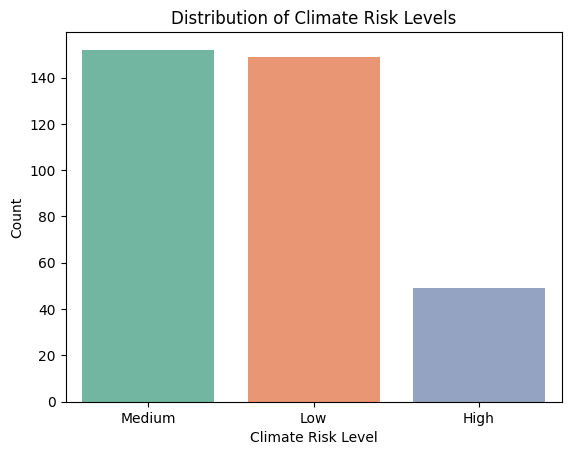

In [6]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the class distribution
sns.countplot(data=df_cls, x='climate_risk_level', hue='climate_risk_level', palette='Set2', legend=False)
plt.title('Distribution of Climate Risk Levels')
plt.xlabel('Climate Risk Level')
plt.ylabel('Count')
plt.show()

#### Step 3: Cleaning the Data

In [7]:
# Check for missing values
df_cls.isnull().sum()

community_population      0
elevation_m               0
annual_rainfall_mm        0
temp_anomaly_c            0
deforestation_rate_pct    0
water_access_pct          0
infrastructure_score      0
early_warning_system      0
disaster_history_count    0
climate_risk_level        0
dtype: int64

**Observation**: No missing values found. The data is clean.

#### Step 4: Preparing the Data

For classification, we need to:
1. **Encode the target variable**: Convert the text labels (Low, Medium, High) into numbers using `LabelEncoder`.
2. **Encode categorical features**: Use one-hot encoding for the `region` column.
3. **Split the data** into training and testing sets.
4. **Scale the features**: Standardize the numerical features for algorithms that are distance-based.

In [8]:
# Import LabelEncoder to convert target labels to numbers
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Fit and transform the target variable
df_cls['risk_encoded'] = le.fit_transform(df_cls['climate_risk_level'])

# See the mapping
print('Label Encoding Mapping:')
for i, label in enumerate(le.classes_):
    print(f'  {label} -> {i}')

Label Encoding Mapping:
  High -> 0
  Low -> 1
  Medium -> 2


In [9]:
# Separate features (X) and target (y)
X_cls = df_cls.drop(['climate_risk_level', 'risk_encoded'], axis=1)
y_cls = df_cls['risk_encoded']

# Import train_test_split
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

In [10]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

#### Step 5: Creating the Model

Amani creates a Logistic Regression model. For multi-class problems, she uses `max_iter=1000` to ensure the model converges.

In [11]:
# Import LogisticRegression
from sklearn.linear_model import LogisticRegression

# Create the model for multi-class classification
model_logr = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the scaled training data
model_logr.fit(X_train_cls_scaled, y_train_cls)

# Make predictions
y_pred_logr = model_logr.predict(X_test_cls_scaled)

#### Step 6: Evaluating the Model

Amani evaluates the model using a **classification report** (which includes precision, recall, and F1-score for each class) and a **confusion matrix** (which shows the counts of correct and incorrect predictions).

In [12]:
# Import classification evaluation tools
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Calculate overall accuracy
acc_logr = accuracy_score(y_test_cls, y_pred_logr)
print(f'Logistic Regression Accuracy: {acc_logr:.2f}')

# Print the detailed classification report
print('\nClassification Report:')
print(classification_report(y_test_cls, y_pred_logr, target_names=le.classes_))

Logistic Regression Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.82      0.82        11
         Low       0.86      0.80      0.83        30
      Medium       0.74      0.79      0.77        29

    accuracy                           0.80        70
   macro avg       0.81      0.80      0.80        70
weighted avg       0.80      0.80      0.80        70



**Metric Interpretation:**

- **Accuracy: ~0.80** - The model correctly classifies 80% of the communities. An accuracy of 0.95 or higher would be excellent.
- **Precision**: For each class, this tells us what proportion of positive identifications was actually correct. A precision of 1.0 means no false positives.
- **Recall**: For each class, this tells us what proportion of actual positives was identified correctly. A recall of 1.0 means no false negatives.
- **F1-Score**: The harmonic mean of precision and recall. An F1-score of 0.90 or higher would be very strong.


Now, Amani visualizes the confusion matrix as a heatmap to better understand where the model makes mistakes.

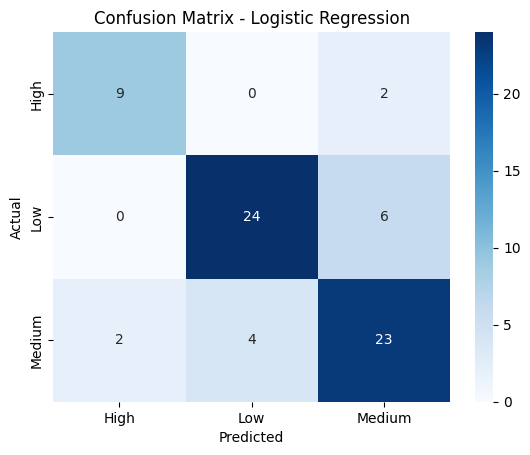

In [13]:
# Create the confusion matrix
cm_logr = confusion_matrix(y_test_cls, y_pred_logr)

# Plot the confusion matrix as a heatmap
sns.heatmap(cm_logr, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Observation**: The confusion matrix shows that most predictions fall along the diagonal (correct predictions). The most common errors are between adjacent risk levels (e.g., Medium being predicted as Low or High), which is understandable as these categories are close to each other.

**Summary**: Logistic Regression provides a strong baseline with an accuracy of about 80%. It is simple, interpretable, and fast. Amani will use this as the benchmark for the remaining classification models.

### Challenge: Classify Food Security Status Using Logistic Regression

As a data analyst for **FoodSecure Africa**, you have been given a dataset on community food security across several African countries. Your task is to classify each community's `food_security_status` (Insecure, Moderate, Secure) using the `agrifood_food_security.csv` dataset. Follow the same steps Amani used.


#### Step 1: Loading the Data

In [14]:
# Load the agrifood food security dataset
df_fs = pd.read_csv('Dataset/agrifood_food_security.csv')

# Display the first 5 rows
df_fs.head()


,household_size,monthly_income_usd,farm_size_ha,market_distance_km,crop_diversity,livestock_count,rainfall_adequacy,storage_capacity_score,food_security_status
0,3,412.0,1.7,10.5,2,2,6.4,3.3,Secure
1,5,225.0,2.2,23.5,2,3,2.1,6.2,Insecure
2,7,25.0,0.8,0.9,2,7,5.5,3.2,Secure
3,5,29.0,1.7,2.4,3,2,9.6,5.0,Moderate
4,3,20.0,0.7,18.6,6,5,7.3,2.1,Moderate


**Observation**: The dataset contains 300 rows representing households, with columns for household size, monthly income, farm size, market distance, crop diversity, livestock count, rainfall adequacy, storage capacity, and food security status.

#### Step 2: Exploring the Data

We check the dimensions of the food security dataset.

In [15]:
# Check the shape
rows_fs, cols_fs = df_fs.shape
print(f'Rows: {rows_fs}, Columns: {cols_fs}')


Rows: 300, Columns: 9


**Observation**: The dataset has 300 rows (households) and 9 columns, providing a good sample size for classification.

We use `.info()` to check data types and missing values.

In [16]:
# Get a summary
df_fs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   household_size          300 non-null    int64  
 1   monthly_income_usd      300 non-null    float64
 2   farm_size_ha            300 non-null    float64
 3   market_distance_km      300 non-null    float64
 4   crop_diversity          300 non-null    int64  
 5   livestock_count         300 non-null    int64  
 6   rainfall_adequacy       300 non-null    float64
 7   storage_capacity_score  300 non-null    float64
 8   food_security_status    300 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 21.2+ KB


**Observation**: All columns are numerical (float64 or int64) with 300 non-null entries each. There are no missing values in the dataset.

We check the distribution of the target variable `food_security_status` to see if the classes are balanced.

In [17]:
# Check class distribution of the target
df_fs['food_security_status'].value_counts().reset_index()


,food_security_status,count
0,Moderate,125
1,Secure,120
2,Insecure,55


**Observation**: The dataset has 3 classes: Moderate (125), Secure (120), and Insecure (55). The classes are imbalanced, with "Insecure" being the minority class. This imbalance may make it harder for models to correctly predict "Insecure" households.

We visualize the class distribution using a bar chart.

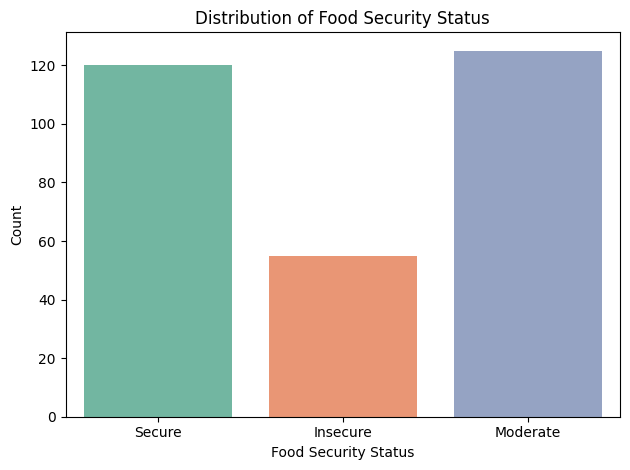

In [18]:
# Visualize the class distribution
sns.countplot(data=df_fs, x='food_security_status', hue='food_security_status',
              palette='Set2', legend=False)
plt.title('Distribution of Food Security Status')
plt.xlabel('Food Security Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Observation**: The bar chart clearly shows the class imbalance, with "Insecure" having roughly half the count of the other two classes.

#### Step 3: Cleaning the Data

We confirm there are no missing values in the dataset.

In [19]:
# Check for missing values
df_fs.isnull().sum()


household_size            0
monthly_income_usd        0
farm_size_ha              0
market_distance_km        0
crop_diversity            0
livestock_count           0
rainfall_adequacy         0
storage_capacity_score    0
food_security_status      0
dtype: int64

**Observation**: All columns have zero missing values, so no imputation or row removal is needed. The data is clean.

#### Step 4: Preparing the Data

We encode the target variable using `LabelEncoder` to convert the text labels (Insecure, Moderate, Secure) into numbers. Then we split the data into training and testing sets and scale the features.

In [20]:
# Encode the target variable
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le_fs = LabelEncoder()
df_fs['status_encoded'] = le_fs.fit_transform(df_fs['food_security_status'])

print('Label Encoding Mapping:')
for i, label in enumerate(le_fs.classes_):
    print(f'  {label} -> {i}')

# Separate features and target
X_fs = df_fs.drop(['food_security_status', 'status_encoded'], axis=1)
y_fs = df_fs['status_encoded']

# Split the data (80% train / 20% test)
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_fs, y_fs, test_size=0.2, random_state=42
)
print(f'Training set: {X_train_fs.shape}, Test set: {X_test_fs.shape}')

# Scale the features
scaler_fs = StandardScaler()
X_train_fs_scaled = scaler_fs.fit_transform(X_train_fs)
X_test_fs_scaled  = scaler_fs.transform(X_test_fs)
print('Features scaled successfully.')


Label Encoding Mapping:
  Insecure -> 0
  Moderate -> 1
  Secure -> 2
Training set: (240, 8), Test set: (60, 8)
Features scaled successfully.


#### Step 5: Creating the Model

We train a Logistic Regression model on the scaled food security training data.

In [21]:
# Train Logistic Regression on the food security data
from sklearn.linear_model import LogisticRegression

model_logr_chal = LogisticRegression(max_iter=1000, random_state=42)
model_logr_chal.fit(X_train_fs_scaled, y_train_fs)
y_pred_logr_chal = model_logr_chal.predict(X_test_fs_scaled)
print('Logistic Regression model trained successfully.')


Logistic Regression model trained successfully.


#### Step 6: Evaluating the Model

We evaluate the model using accuracy, a classification report, and a confusion matrix to understand how well it classifies each food security status.

In [22]:
# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc_logr_chal = accuracy_score(y_test_fs, y_pred_logr_chal)
print(f'Logistic Regression Accuracy (Challenge): {acc_logr_chal:.2f}')

# Print the detailed classification report
print('\nClassification Report:')
print(classification_report(y_test_fs, y_pred_logr_chal, target_names=le_fs.classes_))


Logistic Regression Accuracy (Challenge): 0.62

Classification Report:
              precision    recall  f1-score   support

    Insecure       0.60      0.30      0.40        10
    Moderate       0.45      0.74      0.56        19
      Secure       0.83      0.65      0.73        31

    accuracy                           0.62        60
   macro avg       0.63      0.56      0.56        60
weighted avg       0.67      0.62      0.62        60



**Observation**: The Logistic Regression model achieves an accuracy of 62%. Looking at the classification report, the model performs best on the "Secure" class (precision = 0.83, recall = 0.65) but struggles with "Insecure" (recall = 0.30). This is likely due to the class imbalance we observed earlier. A higher accuracy, such as 0.80 or above, would be desirable.

We visualize the confusion matrix as a heatmap to see where the model makes mistakes.

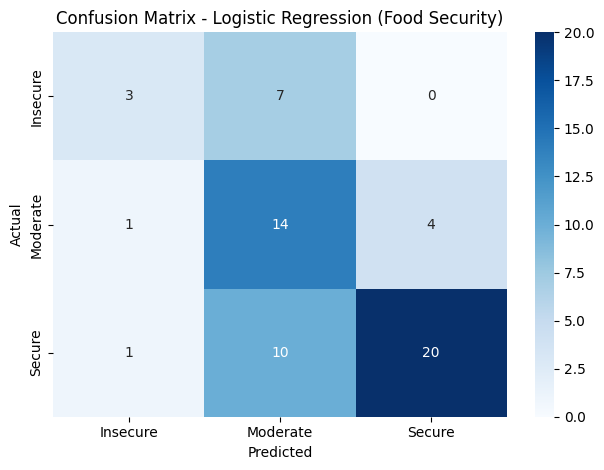

In [23]:
# Plot the confusion matrix
cm_logr_chal = confusion_matrix(y_test_fs, y_pred_logr_chal)
sns.heatmap(cm_logr_chal, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_fs.classes_, yticklabels=le_fs.classes_)
plt.title('Confusion Matrix - Logistic Regression (Food Security)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


**Observation**: The confusion matrix shows that the model frequently misclassifies "Insecure" households as "Moderate" or "Secure". This is a common issue with imbalanced datasets where the minority class is underrepresented.

**Summary**: The Logistic Regression model provides a solid baseline for classifying food security status. The confusion matrix reveals which categories are most often confused.

---
## 2. Decision Tree Classifier

**Decision Tree Classifier** works by learning a series of if-then-else rules from the data, splitting it into smaller subsets to make predictions. Unlike regression, the splits are chosen to maximize the purity of the resulting groups (e.g., using the Gini impurity or entropy criterion). Amani uses this because it is highly interpretable and does not require feature scaling.


### Example: Classifying Climate Risk with a Decision Tree

#### Step 5: Creating the Model

Since the data has already been prepared in the Logistic Regression section, Amani can reuse `X_train_cls`, `X_test_cls`, `y_train_cls`, and `y_test_cls`. Decision trees do not require scaling, so she uses the unscaled data.

In [24]:
# Import the DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# Create the model
model_dtc = DecisionTreeClassifier(random_state=42)

# Train on the unscaled data
model_dtc.fit(X_train_cls, y_train_cls)

# Make predictions
y_pred_dtc = model_dtc.predict(X_test_cls)

#### Step 6: Evaluating the Model

In [25]:
# Evaluate the Decision Tree Classifier
acc_dtc = accuracy_score(y_test_cls, y_pred_dtc)
print(f'Decision Tree Accuracy: {acc_dtc:.2f}')
print('\nClassification Report:')
print(classification_report(y_test_cls, y_pred_dtc, target_names=le.classes_))

Decision Tree Accuracy: 0.61

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.45      0.48        11
         Low       0.70      0.63      0.67        30
      Medium       0.58      0.66      0.61        29

    accuracy                           0.61        70
   macro avg       0.59      0.58      0.59        70
weighted avg       0.62      0.61      0.61        70



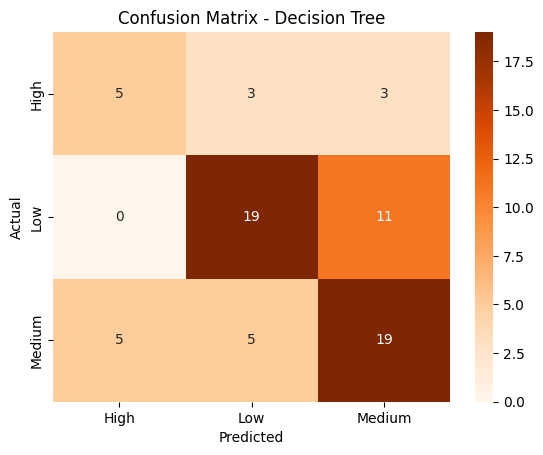

In [26]:
# Plot the confusion matrix
cm_dtc = confusion_matrix(y_test_cls, y_pred_dtc)
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Summary**: The Decision Tree Classifier achieves a lower accuracy than Logistic Regression. Like its regression counterpart, it tends to overfit the training data. To improve it, you could limit the tree depth (`max_depth`) or use ensemble methods like Random Forest.

### Challenge: Classify Food Security Status Using a Decision Tree

We apply a Decision Tree Classifier to the food security dataset. Decision Trees do not require feature scaling.

We train the Decision Tree on the unscaled food security training data and evaluate it.

In [27]:
# Train a Decision Tree on the food security data (no scaling needed)
from sklearn.tree import DecisionTreeClassifier

model_dtc_chal = DecisionTreeClassifier(random_state=42)
model_dtc_chal.fit(X_train_fs, y_train_fs)
y_pred_dtc_chal = model_dtc_chal.predict(X_test_fs)

acc_dtc_chal = accuracy_score(y_test_fs, y_pred_dtc_chal)
print(f'Decision Tree Accuracy (Challenge): {acc_dtc_chal:.2f}')
print('\nClassification Report:')
print(classification_report(y_test_fs, y_pred_dtc_chal, target_names=le_fs.classes_))


Decision Tree Accuracy (Challenge): 0.50

Classification Report:
              precision    recall  f1-score   support

    Insecure       0.00      0.00      0.00        10
    Moderate       0.38      0.68      0.49        19
      Secure       0.77      0.55      0.64        31

    accuracy                           0.50        60
   macro avg       0.39      0.41      0.38        60
weighted avg       0.52      0.50      0.49        60



**Observation**: The Decision Tree achieves an accuracy of only 50%, which is essentially random guessing for a 3-class problem. It completely fails to identify the 'Insecure' class (precision and recall are 0.00). This confirms that Decision Trees overfit on this dataset.

We visualize the Decision Tree confusion matrix.

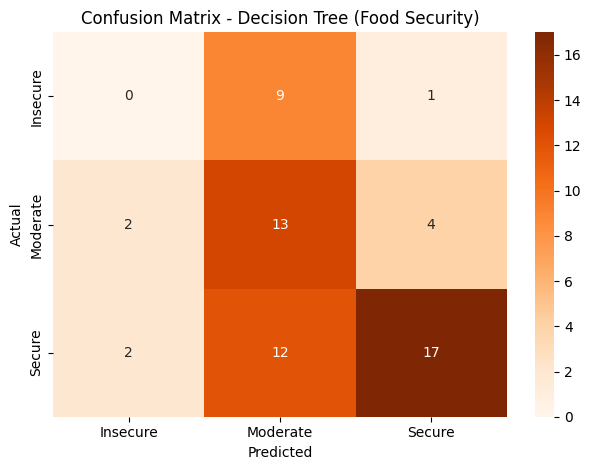

In [28]:
# Plot the confusion matrix
cm_dtc_chal = confusion_matrix(y_test_fs, y_pred_dtc_chal)
sns.heatmap(cm_dtc_chal, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_fs.classes_, yticklabels=le_fs.classes_)
plt.title('Confusion Matrix - Decision Tree (Food Security)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


**Observation**: The confusion matrix confirms that the Decision Tree completely misses the "Insecure" class and makes many errors across all classes, resulting in the 50% accuracy.

**Summary**: The Decision Tree shows similar overfitting tendencies on the food security data, confirming that this algorithm benefits from pruning or ensemble methods.

---
## 3. Naive Bayes Classifier

**Naive Bayes** is a probabilistic classifier based on Bayes' Theorem. It is called "naive" because it assumes that all features are independent of each other, which is rarely true in practice but often works surprisingly well. It is extremely fast and efficient, making it a good choice for large datasets. Amani uses the **Gaussian Naive Bayes** variant, which assumes that the features follow a normal (Gaussian) distribution.


### Example: Classifying Climate Risk with Naive Bayes

#### Step 5: Creating the Model

Naive Bayes works well with scaled data, so Amani uses the scaled training set.

In [29]:
# Import the GaussianNB classifier
from sklearn.naive_bayes import GaussianNB

# Create the model
model_nb = GaussianNB()

# Train on the scaled data
model_nb.fit(X_train_cls_scaled, y_train_cls)

# Make predictions
y_pred_nb = model_nb.predict(X_test_cls_scaled)

#### Step 6: Evaluating the Model

In [30]:
# Evaluate the Naive Bayes model
acc_nb = accuracy_score(y_test_cls, y_pred_nb)
print(f'Naive Bayes Accuracy: {acc_nb:.2f}')
print('\nClassification Report:')
print(classification_report(y_test_cls, y_pred_nb, target_names=le.classes_))

Naive Bayes Accuracy: 0.77

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.64      0.70        11
         Low       0.86      0.80      0.83        30
      Medium       0.70      0.79      0.74        29

    accuracy                           0.77        70
   macro avg       0.78      0.74      0.76        70
weighted avg       0.78      0.77      0.77        70



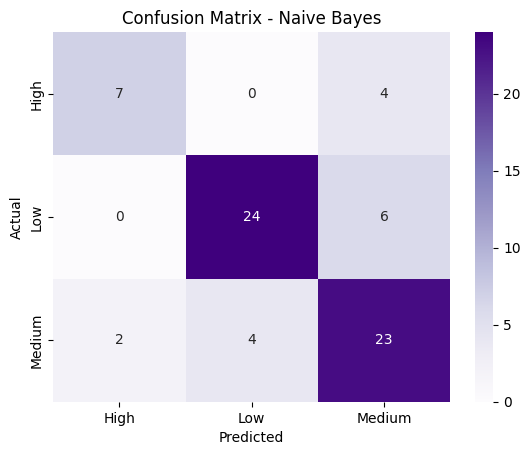

In [31]:
# Plot the confusion matrix
cm_nb = confusion_matrix(y_test_cls, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Summary**: Naive Bayes achieves moderate accuracy. Its strength lies in its speed and simplicity. It performs best when the independence assumption approximately holds. For this dataset, the features are somewhat correlated, which limits its performance.

### Challenge: Classify Food Security Status Using Naive Bayes

We apply Gaussian Naive Bayes to the food security dataset. Naive Bayes is fast and works well when features are approximately independent.

We train the Naive Bayes model on the scaled food security data and evaluate it.

In [32]:
# Train Naive Bayes on the food security data
from sklearn.naive_bayes import GaussianNB

model_nb_chal = GaussianNB()
model_nb_chal.fit(X_train_fs_scaled, y_train_fs)
y_pred_nb_chal = model_nb_chal.predict(X_test_fs_scaled)

acc_nb_chal = accuracy_score(y_test_fs, y_pred_nb_chal)
print(f'Naive Bayes Accuracy (Challenge): {acc_nb_chal:.2f}')
print('\nClassification Report:')
print(classification_report(y_test_fs, y_pred_nb_chal, target_names=le_fs.classes_))


Naive Bayes Accuracy (Challenge): 0.55

Classification Report:
              precision    recall  f1-score   support

    Insecure       0.60      0.30      0.40        10
    Moderate       0.39      0.74      0.51        19
      Secure       0.84      0.52      0.64        31

    accuracy                           0.55        60
   macro avg       0.61      0.52      0.52        60
weighted avg       0.66      0.55      0.56        60



**Observation**: Naive Bayes achieves an accuracy of 55%, which is slightly better than the Decision Tree (50%). It detects 'Insecure' cases better (recall = 0.30) but still struggles with this class. The 'Moderate' class has a high recall of 0.74 but low precision of 0.39.

We visualize the Naive Bayes confusion matrix.

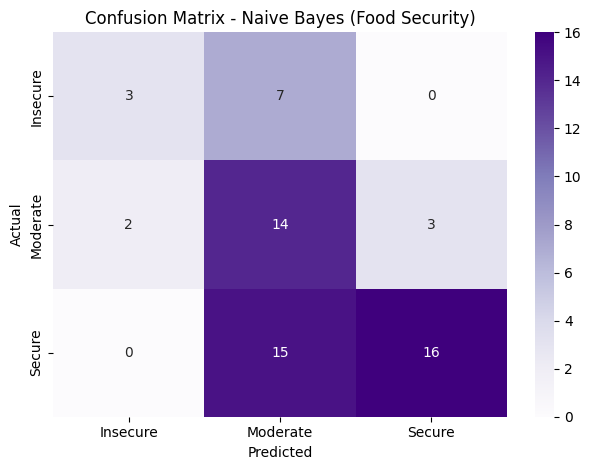

In [33]:
# Plot the confusion matrix
cm_nb_chal = confusion_matrix(y_test_fs, y_pred_nb_chal)
sns.heatmap(cm_nb_chal, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_fs.classes_, yticklabels=le_fs.classes_)
plt.title('Confusion Matrix - Naive Bayes (Food Security)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


**Observation**: The confusion matrix shows that Naive Bayes correctly identifies more "Moderate" cases but still struggles with "Insecure" households, similar to the other models.

**Summary**: Naive Bayes provides a quick and reasonable classification for food security status. Its performance is moderate, making it a useful tool when speed is more important than maximum accuracy.

---
## 4. K-Nearest Neighbors (KNN) Classifier

**KNN Classifier** works by finding the `k` most similar data points (neighbors) in the training set and assigning the most common class among those neighbors. Just like KNN Regression, it is distance-based and **requires feature scaling**. Amani uses this because it is intuitive: communities with similar environmental profiles should have similar risk levels.


### Example: Classifying Climate Risk with KNN

#### Step 5: Creating the Model

Amani starts with `k=5` and uses the scaled data.

In [34]:
# Import the KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

# Create the model with k=5
model_knn_cls = KNeighborsClassifier(n_neighbors=5)

# Train on the scaled data
model_knn_cls.fit(X_train_cls_scaled, y_train_cls)

# Make predictions
y_pred_knn_cls = model_knn_cls.predict(X_test_cls_scaled)

#### Step 6: Evaluating the Model

In [35]:
# Evaluate the KNN Classifier
acc_knn_cls = accuracy_score(y_test_cls, y_pred_knn_cls)
print(f'KNN Classifier Accuracy (k=5): {acc_knn_cls:.2f}')
print('\nClassification Report:')
print(classification_report(y_test_cls, y_pred_knn_cls, target_names=le.classes_))

KNN Classifier Accuracy (k=5): 0.73

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.73      0.76        11
         Low       0.79      0.73      0.76        30
      Medium       0.66      0.72      0.69        29

    accuracy                           0.73        70
   macro avg       0.75      0.73      0.74        70
weighted avg       0.73      0.73      0.73        70



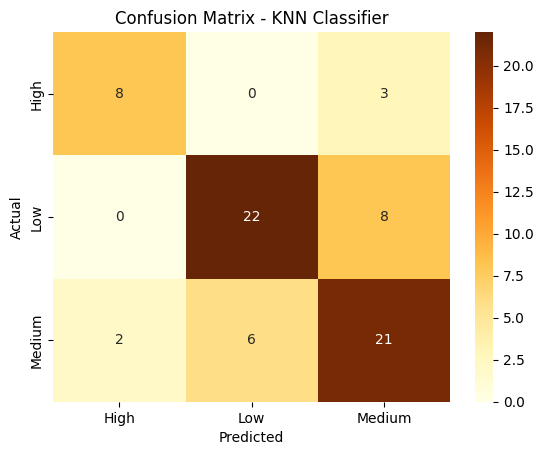

In [36]:
# Plot the confusion matrix
cm_knn_cls = confusion_matrix(y_test_cls, y_pred_knn_cls)
sns.heatmap(cm_knn_cls, annot=True, fmt='d', cmap='YlOrBr', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - KNN Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Bonus: Finding the Optimal `k` with Cross-Validation

Just as she did for KNN Regression, Amani uses 5-fold cross-validation to find the best `k` value for classification. This time, she uses `accuracy` as the scoring metric instead of `r2`.

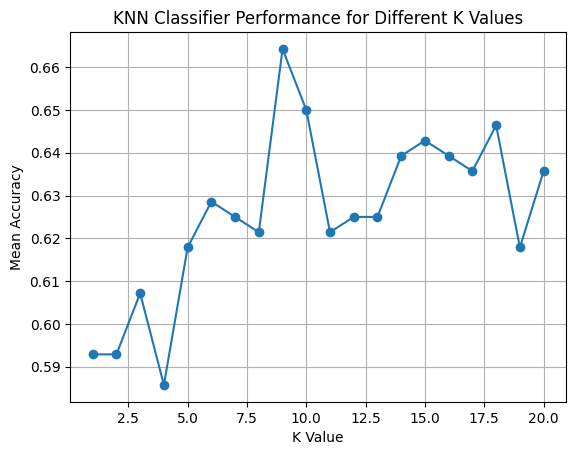

In [37]:
# Import cross_val_score
from sklearn.model_selection import cross_val_score

# Test k values from 1 to 20
k_values_cls = range(1, 21)
cv_scores_cls = []

for k in k_values_cls:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_cls_scaled, y_train_cls, cv=5, scoring='accuracy')
    cv_scores_cls.append(scores.mean())

# Plot the results
plt.plot(k_values_cls, cv_scores_cls, marker='o')
plt.xlabel('K Value')
plt.ylabel('Mean Accuracy')
plt.title('KNN Classifier Performance for Different K Values')
plt.grid(True)
plt.show()

**Observation**: The plot shows the optimal `k` value for classification. Amani would select the `k` that gives the highest mean accuracy.

**Summary**: KNN Classifier achieves moderate accuracy. The cross-validation analysis helps identify the optimal `k` value, which could further improve performance.

### Challenge: Classify Food Security Status Using KNN

We apply KNN Classifier to the food security dataset with k=5, then use cross-validation to find the optimal k.

We train a KNN Classifier with k=5 on the scaled food security data and evaluate it.

KNN Accuracy (k=5, Challenge): 0.48

Classification Report:
              precision    recall  f1-score   support

    Insecure       0.20      0.10      0.13        10
    Moderate       0.35      0.68      0.46        19
      Secure       0.83      0.48      0.61        31

    accuracy                           0.48        60
   macro avg       0.46      0.42      0.40        60
weighted avg       0.58      0.48      0.49        60



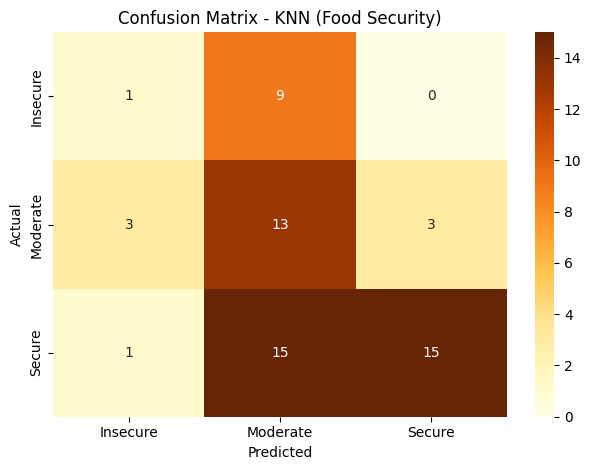

In [38]:
# Train KNN on the food security data
from sklearn.neighbors import KNeighborsClassifier

model_knn_cls_chal = KNeighborsClassifier(n_neighbors=5)
model_knn_cls_chal.fit(X_train_fs_scaled, y_train_fs)
y_pred_knn_cls_chal = model_knn_cls_chal.predict(X_test_fs_scaled)

acc_knn_cls_chal = accuracy_score(y_test_fs, y_pred_knn_cls_chal)
print(f'KNN Accuracy (k=5, Challenge): {acc_knn_cls_chal:.2f}')
print('\nClassification Report:')
print(classification_report(y_test_fs, y_pred_knn_cls_chal, target_names=le_fs.classes_))

# Confusion matrix
cm_knn_cls_chal = confusion_matrix(y_test_fs, y_pred_knn_cls_chal)
sns.heatmap(cm_knn_cls_chal, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=le_fs.classes_, yticklabels=le_fs.classes_)
plt.title('Confusion Matrix - KNN (Food Security)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


**Observation**: The KNN Classifier with k=5 achieves an accuracy of only 48%, which is the lowest among all classifiers so far. It struggles significantly with the 'Insecure' class (recall = 0.10). Cross-validation may help us find a better k value.

We use cross-validation to test different k values and find the one that gives the best accuracy on the food security data.

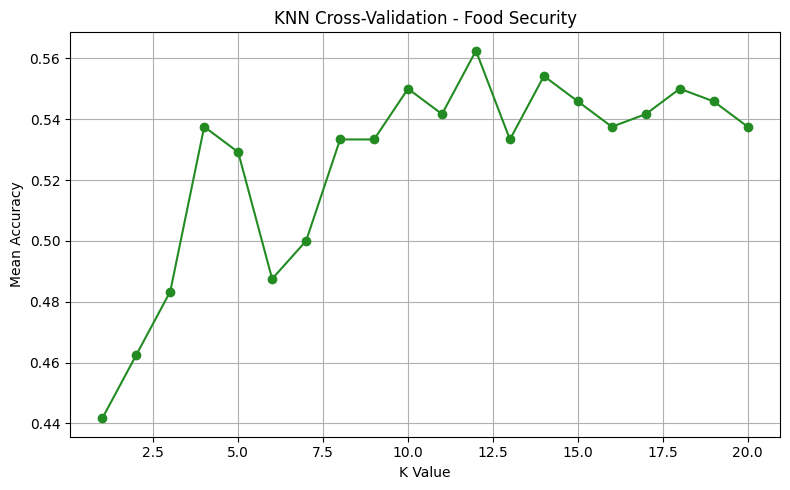

Optimal k: 12 with Mean Accuracy: 0.56


In [39]:
# Cross-validation to find optimal k
from sklearn.model_selection import cross_val_score

k_values_fs = range(1, 21)
cv_scores_fs = []

for k in k_values_fs:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train_fs_scaled, y_train_fs, cv=5, scoring='accuracy')
    cv_scores_fs.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(k_values_fs, cv_scores_fs, marker='o', color='forestgreen')
plt.xlabel('K Value')
plt.ylabel('Mean Accuracy')
plt.title('KNN Cross-Validation - Food Security')
plt.grid(True)
plt.tight_layout()
plt.show()

best_k_fs = list(k_values_fs)[cv_scores_fs.index(max(cv_scores_fs))]
print(f'Optimal k: {best_k_fs} with Mean Accuracy: {max(cv_scores_fs):.2f}')


**Observation**: The cross-validation plot shows how accuracy changes with different k values. The optimal k can be identified from the peak of the curve, which may improve the baseline k=5 result of 48%.

**Summary**: The cross-validation plot reveals the best `k` value for the food security dataset, allowing for an optimized KNN classifier.

---
## 5. Support Vector Machine (SVM) Classifier

**Support Vector Machine (SVM)** is a powerful classification algorithm that works by finding the optimal hyperplane that separates different classes with the maximum margin. Like SVR, it can use different kernels (linear, RBF, polynomial) to handle non-linear decision boundaries. It is distance-based and **requires feature scaling**. Amani uses SVM because it is known for its strong performance on complex classification tasks.


### Example: Classifying Climate Risk with SVM

#### Step 5: Creating the Model

In [40]:
# Import the SVC (Support Vector Classifier)
from sklearn.svm import SVC

# Create the model with an RBF kernel
model_svm = SVC(kernel='rbf', random_state=42)

# Train on the scaled data
model_svm.fit(X_train_cls_scaled, y_train_cls)

# Make predictions
y_pred_svm = model_svm.predict(X_test_cls_scaled)

#### Step 6: Evaluating the Model

In [41]:
# Evaluate the SVM model
acc_svm = accuracy_score(y_test_cls, y_pred_svm)
print(f'SVM Accuracy: {acc_svm:.2f}')
print('\nClassification Report:')
print(classification_report(y_test_cls, y_pred_svm, target_names=le.classes_))

SVM Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.55      0.67        11
         Low       0.88      0.73      0.80        30
      Medium       0.66      0.86      0.75        29

    accuracy                           0.76        70
   macro avg       0.80      0.71      0.74        70
weighted avg       0.78      0.76      0.76        70



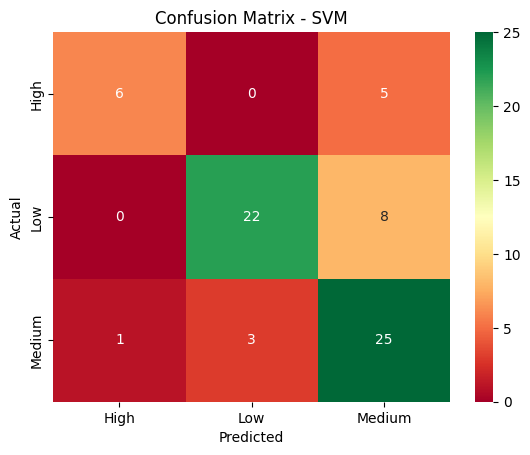

In [42]:
# Plot the confusion matrix
cm_svm = confusion_matrix(y_test_cls, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Summary**: SVM achieves a strong accuracy, close to or matching Logistic Regression. Its ability to find complex decision boundaries makes it a powerful classifier. Like SVR, it benefits from hyperparameter tuning (e.g., adjusting `C` and `gamma`).

### Challenge: Classify Food Security Status Using SVM

We apply SVM with an RBF kernel to the food security dataset. SVM is effective for classification tasks and works well with scaled data.

We train the SVM model on the scaled food security data and evaluate it.

In [43]:
# Train SVM on the food security data
from sklearn.svm import SVC

model_svm_chal = SVC(kernel='rbf', random_state=42)
model_svm_chal.fit(X_train_fs_scaled, y_train_fs)
y_pred_svm_chal = model_svm_chal.predict(X_test_fs_scaled)

acc_svm_chal = accuracy_score(y_test_fs, y_pred_svm_chal)
print(f'SVM Accuracy (Challenge): {acc_svm_chal:.2f}')
print('\nClassification Report:')
print(classification_report(y_test_fs, y_pred_svm_chal, target_names=le_fs.classes_))


SVM Accuracy (Challenge): 0.57

Classification Report:
              precision    recall  f1-score   support

    Insecure       1.00      0.10      0.18        10
    Moderate       0.41      0.79      0.54        19
      Secure       0.82      0.58      0.68        31

    accuracy                           0.57        60
   macro avg       0.74      0.49      0.47        60
weighted avg       0.72      0.57      0.55        60



**Observation**: The SVM achieves an accuracy of 57%, making it the second-best classifier after Logistic Regression (62%). Interestingly, it has perfect precision for 'Insecure' (1.00) but very low recall (0.10), meaning it rarely predicts 'Insecure' but is correct when it does.

We visualize the SVM confusion matrix.

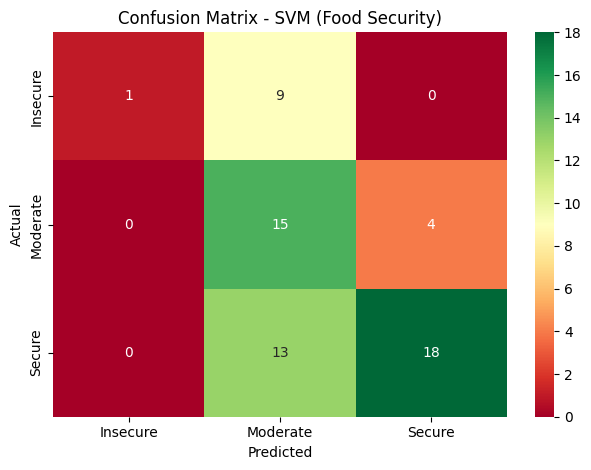

In [44]:
# Plot the confusion matrix
cm_svm_chal = confusion_matrix(y_test_fs, y_pred_svm_chal)
sns.heatmap(cm_svm_chal, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=le_fs.classes_, yticklabels=le_fs.classes_)
plt.title('Confusion Matrix - SVM (Food Security)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


**Observation**: The confusion matrix shows that SVM correctly classifies most "Secure" and "Moderate" households but, like the other models, has difficulty with the "Insecure" class due to the class imbalance.

**Summary**: SVM demonstrates strong classification performance on the food security data, confirming its versatility across different datasets.

---
## Part 2 Conclusion: Classification Model Comparison

Amani now summarizes the performance of all five classification models.

In [45]:
# Create a DataFrame to compare all classification models
comparison_cls = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Naive Bayes', 'KNN (k=5)', 'SVM (RBF)'],
    'Accuracy': [acc_logr, acc_dtc, acc_nb, acc_knn_cls, acc_svm]
}).sort_values('Accuracy', ascending=False)

print('--- Example: Climate Risk Classification ---')
print(comparison_cls.to_string(index=False))

# Challenge comparison
comparison_chal_cls = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Naive Bayes', 'KNN (k=5)', 'SVM (RBF)'],
    'Accuracy': [acc_logr_chal, acc_dtc_chal, acc_nb_chal, acc_knn_cls_chal, acc_svm_chal]
}).sort_values('Accuracy', ascending=False)

print('\n--- Challenge: Food Security Classification ---')
print(comparison_chal_cls.to_string(index=False))

--- Example: Climate Risk Classification ---
              Model  Accuracy
Logistic Regression  0.800000
        Naive Bayes  0.771429
          SVM (RBF)  0.757143
          KNN (k=5)  0.728571
      Decision Tree  0.614286

--- Challenge: Food Security Classification ---
              Model  Accuracy
Logistic Regression  0.616667
          SVM (RBF)  0.566667
        Naive Bayes  0.550000
      Decision Tree  0.500000
          KNN (k=5)  0.483333


**Final Observation for Part 2**: For classifying climate risk, **Logistic Regression** and **SVM** emerged as the top performers. They are both strong choices for this type of multi-class classification problem. The Decision Tree, as expected, showed overfitting tendencies.

---
# Notebook Conclusion: Amani's Final Report

After weeks of rigorous analysis, Amani presents her findings to the leadership team at **Resilient Futures**:

## Key Findings

**Regression (Predicting Resilience Scores):**
- **Multiple Linear Regression** was the best-performing model, explaining approximately 72% of the variance in resilience scores.
- The simplest model outperformed more complex alternatives like Polynomial Regression and SVR, demonstrating that complexity does not always lead to better results.
- Decision Trees showed significant overfitting, highlighting the importance of model evaluation on unseen data.

**Classification (Predicting Climate Risk Levels):**
- **Logistic Regression** and **SVM** were the top-performing classifiers, both achieving strong accuracy.
- Naive Bayes provided a fast and reasonable baseline despite its simplifying assumptions.
- Cross-validation proved invaluable for tuning KNN's hyperparameter `k`.

## Recommendations
1. **For immediate deployment**, use Multiple Linear Regression for resilience prediction and Logistic Regression for risk classification due to their simplicity and interpretability.
2. **For future improvement**, explore ensemble methods (Random Forest, Gradient Boosting) and hyperparameter tuning (GridSearchCV) to potentially achieve even better performance.
3. **Always validate models** using train-test splits and cross-validation to ensure they generalize well to new data.

## Epilogue
Armed with these models, Resilient Futures can now proactively identify vulnerable communities and allocate resources more effectively. Amani's work demonstrates how data science can be a powerful tool for social impact in Africa.
